# Geometric and Physical Interpretation of the Derivative

A guided notebook on **what the derivative *means*** — geometrically and physically.

This notebook explains:
- the **tangent line** as the limit of secant lines
- how the **sign and size** of $f'$ describe the behaviour of $f$
- why extrema have a derivative equal to $0$
- the derivative as **velocity** and as an **instantaneous rate of change** (biology, economics, machine learning)

This notebook follows the same style template as the uploaded guidelines.

## 1. Introduction

You already know *what* a derivative is and *how* to compute it. This notebook is about its **significance**.

Understanding the interpretation turns the derivative from an abstract limit into a practical tool: it lets you read the properties of a function from its slope, and it measures the **instantaneous change** of one variable with respect to another — the growth of a population, the velocity of an object, the marginal cost of a product.

After this notebook you will be able to:
- write the equation of a tangent line at a point,
- use the sign of $f'$ to tell where $f$ increases or decreases,
- interpret $f'(a)$ as a rate of change in physics and other fields.

## 2. The Tangent Line

Consider a function $f : \mathbb{R} \to \mathbb{R}$ and a point $a$ in its domain. The graph of $f$ is a curve, and we want the **tangent line** at the point $P = (a, f(a))$.

Pick any nearby point $x \ne a$, giving $Q = (x, f(x))$. The line through $P$ and $Q$ is a **secant line**, and its slope is

$$
m_{\text{sec}} = \frac{f(x) - f(a)}{x - a}.
$$

As $x$ approaches $a$, the secant slopes approach a limiting value — the **slope of the tangent line**, which is the derivative of $f$ at $a$:

$$
f'(a) = \lim_{x \to a} \frac{f(x) - f(a)}{x - a}.
$$

> A line is fixed by its slope and one point, so the derivative gives us the whole tangent line:
> $$ y = f(a) + f'(a)\,(x - a). $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

### Secant lines approaching the tangent

Let us watch the secant lines of $f(x) = x^2$ at $a = 1$ as the second point $Q$ slides toward $P$. The tangent slope there is $f'(1) = 2$.

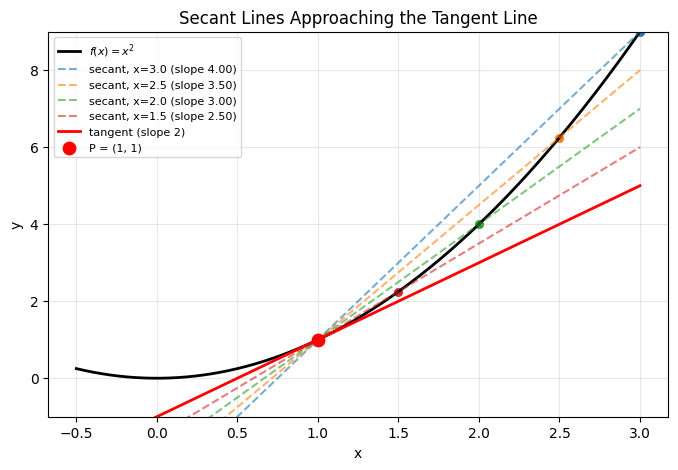

In [2]:
def f(x):
    return x**2

a = 1.0
xs = np.linspace(-0.5, 3, 400)

plt.figure(figsize=(8, 5))
plt.plot(xs, f(xs), label=r"$f(x) = x^2$", linewidth=2, color='black')

# secant lines for points Q getting closer to P
for x_q in [3.0, 2.5, 2.0, 1.5]:
    slope = (f(x_q) - f(a)) / (x_q - a)
    plt.plot(xs, f(a) + slope*(xs - a), '--', alpha=0.6,
             label=f"secant, x={x_q:.1f} (slope {slope:.2f})")
    plt.scatter([x_q], [f(x_q)], s=30)

# the tangent line: slope f'(1) = 2
plt.plot(xs, f(a) + 2*(xs - a), color='red', linewidth=2,
         label="tangent (slope 2)")
plt.scatter([a], [f(a)], color='red', s=80, zorder=5, label='P = (1, 1)')

plt.title('Secant Lines Approaching the Tangent Line')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(True, alpha=0.3); plt.legend(fontsize=8)
plt.ylim(-1, 9)
plt.show()

### Worked example: equation of a tangent line

Find the tangent line to $f(x) = x^2$ at $a = 1$.

$$
f'(x) = 2x \;\Rightarrow\; f'(1) = 2, \qquad f(1) = 1.
$$

Using $y = f(a) + f'(a)(x - a)$:

$$
y = 1 + 2(x - 1) = 2x - 1.
$$

In [3]:
x, a_sym = sp.symbols('x a')
expr = x**2

fp = sp.diff(expr, x)
a_val = 1
tangent = expr.subs(x, a_val) + fp.subs(x, a_val) * (x - a_val)

print("f(x)        =", expr)
print("f'(x)       =", fp)
print("f'(1)       =", fp.subs(x, a_val))
print("tangent at 1:", sp.expand(tangent))

f(x)        = x**2
f'(x)       = 2*x
f'(1)       = 2
tangent at 1: 2*x - 1


## 3. Reading the Curve from the Slope

The slopes of tangent lines reveal a lot about a function:

- When $f'(x) > 0$ on an interval, $f$ is **increasing** there.
- When $f'(x) < 0$ on an interval, $f$ is **decreasing** there.
- The **size** $|f'(x)|$ says **how fast** $f$ changes — steeper tangent, faster change.

And at a maximum or minimum the tangent levels off:

> If $f$ reaches a maximum or minimum at $a$, then $f'(a) = 0$.

Let us see all of this on $f(x) = \tfrac{1}{3}x^3 - x$, whose derivative is $f'(x) = x^2 - 1$ (zero at $x = \pm 1$).

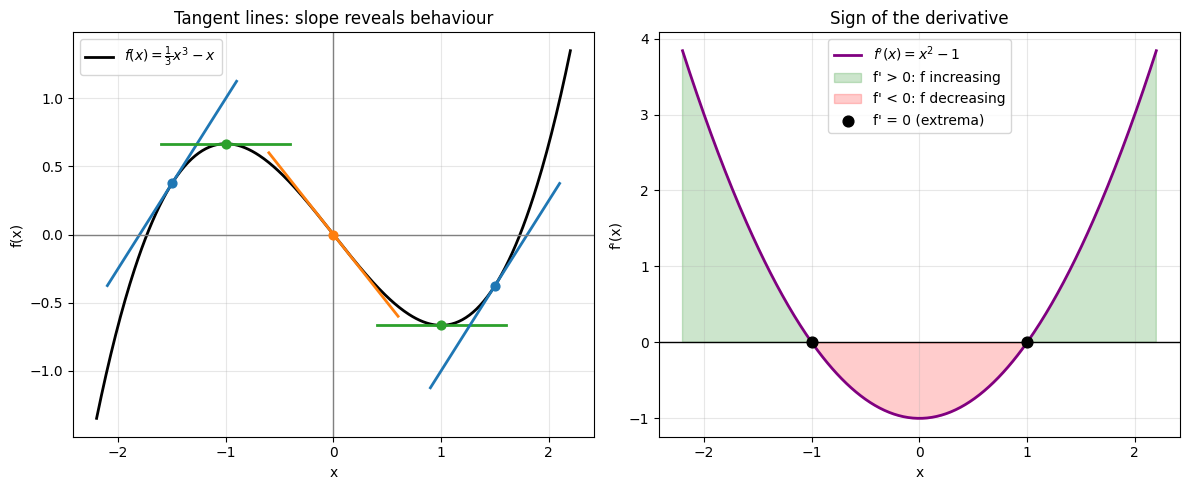

In [4]:
xs = np.linspace(-2.2, 2.2, 400)
ys = (1/3)*xs**3 - xs

def g(x):
    return (1/3)*x**3 - x

def gprime(x):
    return x**2 - 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# left: function with a few tangent lines
ax1.plot(xs, ys, color='black', linewidth=2, label=r"$f(x)=\frac{1}{3}x^3 - x$")
for pt, color in [(-1.5, 'tab:blue'), (-1, 'tab:green'), (0, 'tab:orange'), (1, 'tab:green'), (1.5, 'tab:blue')]:
    slope = gprime(pt)
    tx = np.linspace(pt - 0.6, pt + 0.6, 20)
    ax1.plot(tx, g(pt) + slope*(tx - pt), color=color, linewidth=2)
    ax1.scatter([pt], [g(pt)], color=color, s=40, zorder=5)
ax1.set_title('Tangent lines: slope reveals behaviour')
ax1.axhline(0, lw=1, color='gray'); ax1.axvline(0, lw=1, color='gray')
ax1.grid(True, alpha=0.3); ax1.legend(); ax1.set_xlabel('x'); ax1.set_ylabel('f(x)')

# right: the derivative, shading increasing / decreasing
ax2.plot(xs, gprime(xs), color='purple', linewidth=2, label=r"$f'(x)=x^2-1$")
ax2.axhline(0, lw=1, color='black')
ax2.fill_between(xs, gprime(xs), 0, where=(gprime(xs) > 0), alpha=0.2, color='green', label="f' > 0: f increasing")
ax2.fill_between(xs, gprime(xs), 0, where=(gprime(xs) < 0), alpha=0.2, color='red',   label="f' < 0: f decreasing")
ax2.scatter([-1, 1], [0, 0], color='black', s=60, zorder=5, label="f' = 0 (extrema)")
ax2.set_title('Sign of the derivative')
ax2.grid(True, alpha=0.3); ax2.legend(); ax2.set_xlabel('x'); ax2.set_ylabel("f'(x)")

plt.tight_layout()
plt.show()

Notice how, on the right plot, the derivative is **negative between $-1$ and $1$** (where the function dips) and **positive outside** (where the function climbs). The derivative crosses zero exactly at the local maximum $x = -1$ and the local minimum $x = 1$.

## 4. Physics: Velocity and Acceleration

Imagine an object moving in a straight line. Its position $s$ is a function of time $t$: $\;s = f(t)$.

Over the time interval $[a, x]$, the **average velocity** compares displacement with elapsed time:

$$
\bar{v} = \frac{f(x) - f(a)}{x - a}.
$$

This is exactly the slope of a secant line! Letting $x \to a$ gives the **instantaneous velocity**:

$$
v(a) = f'(a).
$$

Differentiating velocity in turn gives the instantaneous rate of change of velocity — the **acceleration**.

### Example

A falling object has position $s(t) = 5t^2$ (metres). Then

$$
v(t) = s'(t) = 10t, \qquad a(t) = v'(t) = 10.
$$

At $t = 3$ s the velocity is $v(3) = 30$ m/s and the acceleration is a constant $10\ \text{m/s}^2$.

In [5]:
t = sp.symbols('t')
s = 5*t**2

velocity = sp.diff(s, t)
acceleration = sp.diff(s, t, 2)

print("position  s(t) =", s)
print("velocity  v(t) =", velocity, "   -> v(3) =", velocity.subs(t, 3), "m/s")
print("accel.    a(t) =", acceleration, "  m/s^2 (constant)")

position  s(t) = 5*t**2
velocity  v(t) = 10*t    -> v(3) = 30 m/s
accel.    a(t) = 10   m/s^2 (constant)


Average velocity over [1, x] as x -> 1:
  [1,  3.0]  ->  20.000 m/s
  [1,  2.0]  ->  15.000 m/s
  [1,  1.5]  ->  12.500 m/s
  [1,  1.1]  ->  10.500 m/s
  [1, 1.01]  ->  10.050 m/s
instantaneous velocity v(1) = 10 m/s


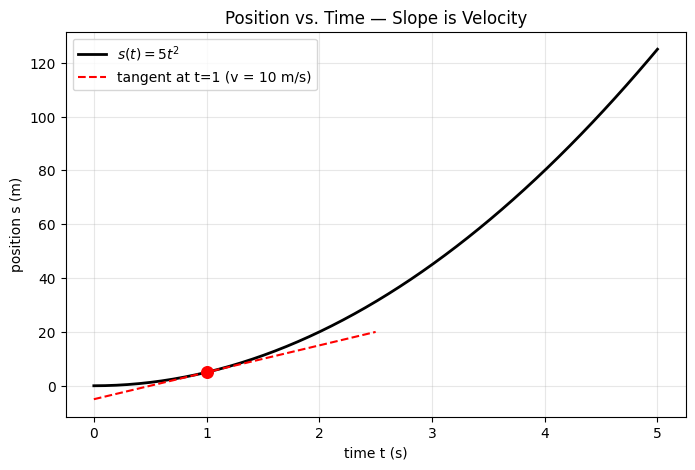

In [6]:
t_vals = np.linspace(0, 5, 200)
position = 5*t_vals**2

# average velocity over [1, x] approaches the instantaneous velocity v(1) = 10
a_pt = 1.0
print("Average velocity over [1, x] as x -> 1:")
for x_pt in [3.0, 2.0, 1.5, 1.1, 1.01]:
    avg = (5*x_pt**2 - 5*a_pt**2) / (x_pt - a_pt)
    print(f"  [1, {x_pt:>4}]  ->  {avg:.3f} m/s")
print("instantaneous velocity v(1) = 10 m/s")

plt.figure(figsize=(8, 5))
plt.plot(t_vals, position, color='black', linewidth=2, label=r"$s(t) = 5t^2$")
# tangent at t = 1 has slope v(1) = 10
tt = np.linspace(0, 2.5, 20)
plt.plot(tt, 5*a_pt**2 + 10*(tt - a_pt), 'r--', label="tangent at t=1 (v = 10 m/s)")
plt.scatter([a_pt], [5*a_pt**2], color='red', s=70, zorder=5)
plt.title('Position vs. Time — Slope is Velocity')
plt.xlabel('time t (s)'); plt.ylabel('position s (m)')
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 5. Rates of Change Everywhere

More generally, if a quantity depends on another through $f$, then

$$
\frac{f(x) - f(a)}{x - a}
$$

is the **average rate of change** over $[a, x]$, and its limit as $x \to a$ — the derivative $f'(a)$ — is the **instantaneous rate of change**.

> The derivative $f'(a)$ denotes the instantaneous rate of change of $f$ at $a$.

This single idea reappears across many fields:

| Field | Quantity $f$ | $f'$ means |
|-------|--------------|------------|
| Biology | population over time | growth rate of the colony |
| Economics | cost vs. units produced | **marginal cost** |
| Electricity | charge through a surface | electric **current** |
| Machine learning | loss vs. parameters | direction & size of the update |

### Biology example: bacterial growth

Suppose a colony grows as $P(t) = 100\,e^{0.5t}$ (individuals, with $t$ in hours). The growth rate is the derivative

$$
P'(t) = 50\,e^{0.5t}.
$$

The rate is itself proportional to the population — a hallmark of exponential growth.

In [7]:
t = sp.symbols('t')
P = 100*sp.exp(sp.Rational(1, 2)*t)
rate = sp.diff(P, t)

print("P(t)  =", P)
print("P'(t) =", rate)
for hour in [0, 2, 4]:
    print(f"  t = {hour}h:  population = {float(P.subs(t, hour)):8.1f},  growth rate = {float(rate.subs(t, hour)):8.1f} per hour")

P(t)  = 100*exp(t/2)
P'(t) = 50*exp(t/2)
  t = 0h:  population =    100.0,  growth rate =     50.0 per hour
  t = 2h:  population =    271.8,  growth rate =    135.9 per hour
  t = 4h:  population =    738.9,  growth rate =    369.5 per hour


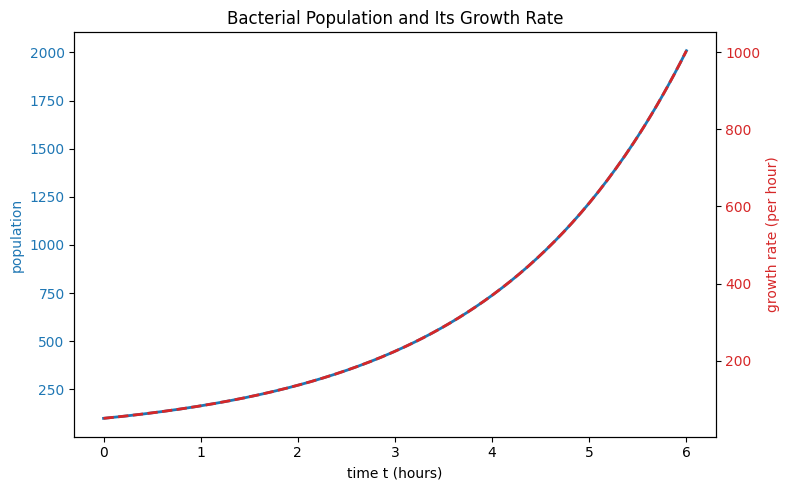

In [8]:
t_vals = np.linspace(0, 6, 200)
pop = 100*np.exp(0.5*t_vals)
growth = 50*np.exp(0.5*t_vals)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(t_vals, pop, color='tab:blue', linewidth=2, label='population P(t)')
ax1.set_xlabel('time t (hours)')
ax1.set_ylabel('population', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(t_vals, growth, color='tab:red', linestyle='--', linewidth=2, label="growth rate P'(t)")
ax2.set_ylabel('growth rate (per hour)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Bacterial Population and Its Growth Rate')
fig.tight_layout()
plt.show()

### Machine learning: gradient descent

In supervised learning we tune model parameters to **minimize a loss function** that measures the gap between predictions and true outputs. The derivative of the loss with respect to a parameter points in the direction (and gives the magnitude) of the adjustment needed.

**Gradient descent** updates a parameter $w$ repeatedly:

$$
w \leftarrow w - \eta\, L'(w),
$$

where $\eta$ is the learning rate. As we near the minimum, $L'(w) \to 0$ and the steps shrink. Below we minimize the toy loss $L(w) = (w - 3)^2$, whose minimum is at $w = 3$.

In [9]:
def loss(w):
    return (w - 3)**2

def loss_prime(w):
    return 2*(w - 3)

w = 0.0           # starting parameter
eta = 0.1         # learning rate
history = [w]

for step in range(15):
    w = w - eta * loss_prime(w)
    history.append(w)

for i, wv in enumerate(history):
    print(f"step {i:2d}:  w = {wv:6.4f},  L(w) = {loss(wv):7.4f},  L'(w) = {loss_prime(wv):7.4f}")

step  0:  w = 0.0000,  L(w) =  9.0000,  L'(w) = -6.0000
step  1:  w = 0.6000,  L(w) =  5.7600,  L'(w) = -4.8000
step  2:  w = 1.0800,  L(w) =  3.6864,  L'(w) = -3.8400
step  3:  w = 1.4640,  L(w) =  2.3593,  L'(w) = -3.0720
step  4:  w = 1.7712,  L(w) =  1.5099,  L'(w) = -2.4576
step  5:  w = 2.0170,  L(w) =  0.9664,  L'(w) = -1.9661
step  6:  w = 2.2136,  L(w) =  0.6185,  L'(w) = -1.5729
step  7:  w = 2.3709,  L(w) =  0.3958,  L'(w) = -1.2583
step  8:  w = 2.4967,  L(w) =  0.2533,  L'(w) = -1.0066
step  9:  w = 2.5973,  L(w) =  0.1621,  L'(w) = -0.8053
step 10:  w = 2.6779,  L(w) =  0.1038,  L'(w) = -0.6442
step 11:  w = 2.7423,  L(w) =  0.0664,  L'(w) = -0.5154
step 12:  w = 2.7938,  L(w) =  0.0425,  L'(w) = -0.4123
step 13:  w = 2.8351,  L(w) =  0.0272,  L'(w) = -0.3299
step 14:  w = 2.8681,  L(w) =  0.0174,  L'(w) = -0.2639
step 15:  w = 2.8944,  L(w) =  0.0111,  L'(w) = -0.2111


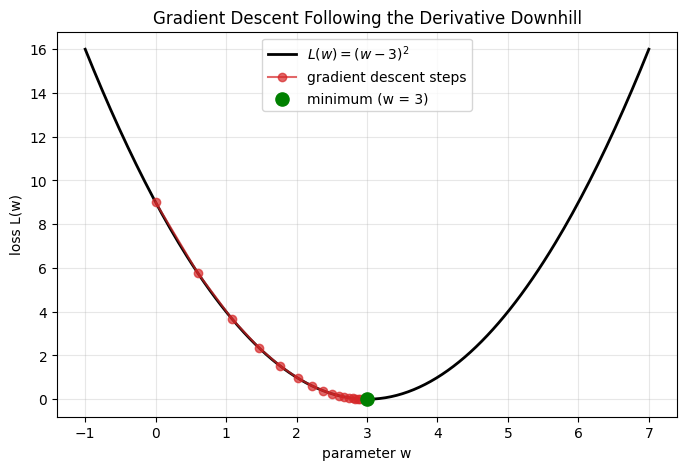

In [10]:
ws = np.linspace(-1, 7, 200)

plt.figure(figsize=(8, 5))
plt.plot(ws, loss(ws), color='black', linewidth=2, label=r"$L(w) = (w-3)^2$")
hist = np.array(history)
plt.plot(hist, loss(hist), 'o-', color='tab:red', alpha=0.7, label='gradient descent steps')
plt.scatter([3], [0], color='green', s=90, zorder=5, label='minimum (w = 3)')
plt.title('Gradient Descent Following the Derivative Downhill')
plt.xlabel('parameter w'); plt.ylabel('loss L(w)')
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 6. Exercises

### Basic

1. Find the equation of the tangent line to $f(x) = x^2 - 4x$ at $a = 1$.
2. On which intervals is $f(x) = x^2 - 4x$ increasing or decreasing? Use the sign of $f'$.

### Intermediate

3. An object has position $s(t) = t^3 - 6t^2 + 9t$. Find its velocity $v(t)$ and the times when the object is momentarily at rest ($v = 0$).
4. For $f(x) = x^3 - 3x$, find all points where the tangent line is horizontal.

### Advanced

5. A colony grows as $P(t) = 200\,e^{0.3t}$. Find the growth rate at $t = 5$, and explain why the rate is proportional to the population.
6. For the loss $L(w) = (w - 2)^2 + 1$, perform two steps of gradient descent by hand starting at $w = 0$ with learning rate $\eta = 0.25$.

## 7. Solutions / Checks

**1.** $f'(x) = 2x - 4$, so $f'(1) = -2$ and $f(1) = -3$. Tangent: $y = -3 - 2(x - 1) = -2x - 1$.

**2.** $f'(x) = 2x - 4 = 0 \Rightarrow x = 2$. Decreasing on $(-\infty, 2)$ (where $f' < 0$), increasing on $(2, \infty)$ (where $f' > 0$).

**3.** $v(t) = 3t^2 - 12t + 9 = 3(t-1)(t-3)$, so the object is at rest at $t = 1$ and $t = 3$.

**4.** $f'(x) = 3x^2 - 3 = 0 \Rightarrow x = \pm 1$. Horizontal tangents at $(-1, 2)$ and $(1, -2)$.

**5.** $P'(t) = 60\,e^{0.3t}$, so $P'(5) = 60\,e^{1.5} \approx 268.9$ per unit time. Since $P'(t) = 0.3\,P(t)$, the rate is proportional to the current population (exponential growth).

**6.** $L'(w) = 2(w - 2)$. Start $w_0 = 0$: $w_1 = 0 - 0.25\cdot(-4) = 1$; then $w_2 = 1 - 0.25\cdot(-2) = 1.5$. The parameter moves toward the minimum at $w = 2$.

Run the cell below to verify these symbolically.

In [11]:
x, t = sp.symbols('x t')

# 1 & 2
f1 = x**2 - 4*x
fp1 = sp.diff(f1, x)
tangent1 = f1.subs(x, 1) + fp1.subs(x, 1)*(x - 1)
print("1. tangent at x=1:", sp.expand(tangent1))
print("2. f'(x) = 0 at x =", sp.solve(fp1, x))

# 3
s3 = t**3 - 6*t**2 + 9*t
v3 = sp.diff(s3, t)
print("3. v(t) =", sp.factor(v3), " -> at rest at t =", sp.solve(v3, t))

# 4
f4 = x**3 - 3*x
print("4. horizontal tangents at x =", sp.solve(sp.diff(f4, x), x))

# 5
P5 = 200*sp.exp(sp.Rational(3, 10)*t)
print("5. P'(5) =", float(sp.diff(P5, t).subs(t, 5)))

1. tangent at x=1: -2*x - 1
2. f'(x) = 0 at x = [2]
3. v(t) = 3*(t - 3)*(t - 1)  -> at rest at t = [1, 3]
4. horizontal tangents at x = [-1, 1]
5. P'(5) = 268.9013442202839


## 8. Conclusion

To sum up:

- The line tangent to the graph of $f$ at $P = (a, f(a))$ runs through $P$ with slope $f'(a)$: &nbsp; $y = f(a) + f'(a)(x - a)$.
- If $f'(x) > 0$ on an interval, $f$ **increases** there; if $f'(x) < 0$, $f$ **decreases**. The size $|f'(x)|$ measures how fast.
- If $f$ reaches a maximum or minimum at $a$, then $f'(a) = 0$.
- The derivative of displacement with respect to time is the **instantaneous velocity**.
- In essence, $f'(a)$ is the **instantaneous rate of change** of $f$ at $a$ — a tool that powers biology, economics, electricity, and the gradient descent at the heart of machine learning.

Key lesson:

$$
f'(a) = \lim_{x \to a} \frac{f(x) - f(a)}{x - a} = \text{slope of the tangent} = \text{instantaneous rate of change}.
$$